# Does a rotten movie tank the studio's stock? 🍅📉
### The "a flop sinks the studio / a hit lifts it" story — tested on 40 big releases and 6 studios

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Flop tanks studio%3F: Overstated](https://img.shields.io/badge/Flop%20tanks%20studio%3F-Overstated-8b949e?style=flat-square)

Every time a big movie gets panned, someone says the studio's stock should take a hit — and when a film is a critical darling, that it should pop. It's a tidy story: reviews are public, dated and loud, so surely they move the company that made the film.

There's an obvious reason to doubt it: these "studios" are gigantic conglomerates. Disney is parks + ESPN + streaming; Comcast is your internet provider + Universal; Sony is PlayStation + camera sensors + music; one movie is a rounding error. So we tested it properly on **40 major releases (2022-2025)** across **six studios** (Disney, Warner Bros. Discovery, Paramount, Comcast/Universal, Netflix, Sony), each tagged **fresh** or **rotten** by critics.

> 📓 **Want the *t*-stats, the placebos and the confound autopsy?** See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rotten_tomatoes import data, strategy as st

FILMS = data.film_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EVENTS = st.build_event_table(PRICES)
else:
    PRICES = EVENTS = None
print("real cache present:", HAVE_REAL, "| films in table:", len(FILMS),
      "|", int((FILMS['tier']=='fresh').sum()), "fresh /",
      int((FILMS['tier']=='rotten').sum()), "rotten")

# frozen headline numbers (mirror of docs/results.md)
R = {'n_films': 40, 'n_fresh': 21, 'n_rotten': 19, 'cal_lo': '2022-04-01', 'cal_hi': '2025-06-20', 'ow_fresh_bps': -110.6, 'ow_fresh_t': -1.65, 'ow_rotten_bps': -98.8, 'ow_rotten_t': -1.45, 'ow_gap_bps': -11.9, 'ow_gap_t': -0.12, 'fw_fresh_bps': 181.1, 'fw_fresh_t': 1.62, 'fw_fresh_nw': 2.51, 'fw_rotten_bps': -634.6, 'fw_rotten_t': -2.14, 'fw_rotten_nw': -2.09, 'fw_gap_bps': 815.7, 'fw_gap_t': 2.58, 'full_fresh_bps': 70.5, 'full_fresh_t': 0.67, 'full_rotten_bps': -733.3, 'full_rotten_t': -2.18, 'full_gap_bps': 803.8, 'full_gap_t': 2.28, 'hit_fresh_k': 17, 'hit_fresh_n': 21, 'hit_fresh_pct': 81.0, 'hit_fresh_wilson': (60.0, 92.3), 'hit_rotten_k': 14, 'hit_rotten_n': 19, 'hit_rotten_pct': 73.7, 'hit_rotten_wilson': (51.2, 88.2), 'perm_obs_bps': 815.7, 'perm_mean_bps': 0.6, 'perm_sd_bps': 328.3, 'perm_p': 0.001, 'perm_draws': 20000, 'rand_obs_bps': -206.3, 'rand_mean_bps': -0.0, 'rand_sd_bps': 119.2, 'rand_p': 0.079, 'rand_draws': 4000, 'timer': {0.0: (396.5, 396.2, 2.56), 5.0: (396.5, 386.2, 2.5)}, 'windows': {'pre [-6..-2]': (-210, -1.26), 'pre [-11..-2]': (-26, -0.11), 'open [0..+1]': (-12, -0.12), 'week [+2..+6]': (816, 2.58), '[+7..+11]': (79, 0.33), '[+15..+20]': (-106, -0.7)}, 'era_2223_gap': 365, 'era_2223_t': 2.03, 'era_2425_gap': 1352, 'era_2425_t': 2.18, 'loo_min_t': 2.16, 'loo_max_t': 2.84, 'trim_gap': 480, 'trim_t': 4.59, 'outlier_if': -4366, 'outlier_marley': -4050, 'syn_null_mean': -0.12, 'syn_null_sd': 0.95, 'syn_null_fire': 0, 'syn_plant_mean': 4.49, 'syn_plant_sd': 1.2, 'syn_plant_fire': 20, 'syn_plant_seed_gap': 349, 'syn_plant_seed_t': 2.78, 'fp_panel': '567671346662', 'fp_spy': 'd57404af997d', 'fp_dis': '1f215beecb34', 'fp_wbd': 'ec1bfa8df210', 'fp_para': '1c6e31d1e522', 'fp_cmcsa': '88dadf4247a2', 'fp_nflx': 'a538858b0952', 'fp_sony': 'ba00ad7266b7'}


real cache present: True | films in table: 40 | 21 fresh / 19 rotten


## The answer first

| Question | Answer |
|---|---|
| On the **release weekend** — when the reviews are already out — do rotten films' studios drop more than fresh ones'? | **No.** The fresh-minus-rotten gap is **-11.9 bps** (basically zero, and the *wrong* sign). The one window where a review effect should be sharpest shows nothing. |
| In the **following week**, is there a gap? | **Yes — and it's real in-sample** (+816 bps, hard to get by luck). But it only shows up in *that one* week, it reverses afterward, and it's way too big to be a movie. |
| So — does a flop tank the studio? | **Overstated.** What actually happens is subtler and not really about the film: struggling studios make *both* worse movies *and* worse stock returns in the same stretch. |
| Could you trade it? | **Only on paper.** A fresh-long / rotten-short book "works" in this 40-trade backtest — but it's riding that one fragile window and one giant unrelated crash. |

> A loud, intuitive story — and the clean version of the test comes back empty.

## 1 · The claim

> *"A movie's Rotten Tomatoes score is a public verdict on the studio's product. A rotten score is a flop in the making — sell the studio. A fresh score is a hit — buy it."*

It sounds airtight because reviews really are public and dated. The catch is **scale**: a single film, even a $250M tentpole, is a tiny slice of a $100-200bn conglomerate's revenue — and a lot of the box-office outcome is already anticipated (tracking, pre-sales) before opening. So the efficient- markets prior is that a known, small, largely-expected event barely moves the parent.

## 2 · So what?

If it were real *and* tradable, you'd have a clean event edge: read the Tomatometer on release day, go long the fresh studios and short the rotten ones. So we ask three things: does the studio move on the **release weekend**, does it move in the **following week**, and could you **trade** the split?

## 3 · How would we even know?

- **The films.** 40 major wide releases 2022-04-01 → 2025-06-20 (21 clearly-fresh ≥ 75, 19 clearly-rotten < 50 — mixed 50-74 titles left out so the contrast is clean).
- **The instrument.** The *distributing studio's* stock (DIS/WBD/PARA/CMCSA/NFLX/SONY), measured against the S&P 500 so we see the studio's *own* move, not the market's.
- **Two windows.** The **opening weekend** (release day + next session) and the **following week** (the next five sessions).
- **The luck check.** Shuffle the fresh/rotten labels 20,000 times — how often does a random relabelling produce a gap this big?

## 4 · The teardown — let's actually look

**First, the clean test: the release weekend.** Reviews are already public, so if critics move the stock, it should show here. Fresh vs rotten:

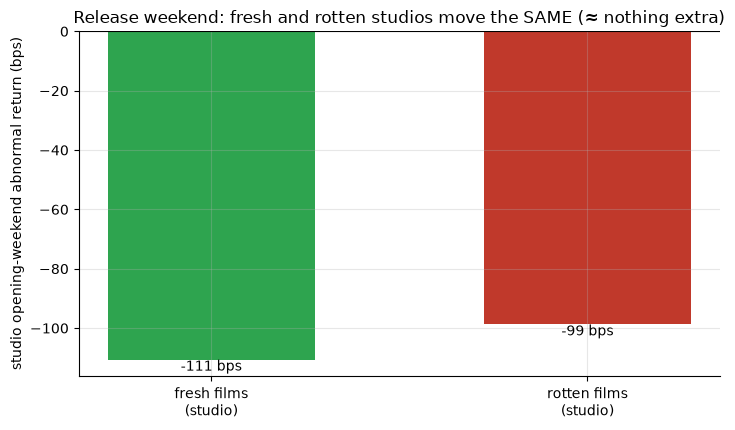

opening-weekend gap fresh-rotten = -11.9 bps  (R: -11.9)


In [2]:
if HAVE_REAL:
    ts = st.tier_stats(EVENTS, col='ow_car')
    fb, rb = ts['fresh_bps'], ts['rotten_bps']
else:
    fb, rb = R['ow_fresh_bps'], R['ow_rotten_bps']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['fresh films\n(studio)', 'rotten films\n(studio)'], [fb, rb],
       color=[GREEN, RED], width=.55)
for i, v in enumerate([fb, rb]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('studio opening-weekend abnormal return (bps)')
ax.set_title('Release weekend: fresh and rotten studios move the SAME (≈ nothing extra)')
plt.tight_layout(); plt.show()
print(f'opening-weekend gap fresh-rotten = {fb-rb:+.1f} bps  (R: {R["ow_gap_bps"]:+.1f})')

Both tiers wobble slightly *down* on release (a mechanical "sell the release" tic every big film shares), and the **gap is -11.9 bps** — essentially zero, if anything the wrong sign. **On the window where a review effect should be loudest, there is none.**

**Now the following week.** Here — and *only* here — a gap appears:

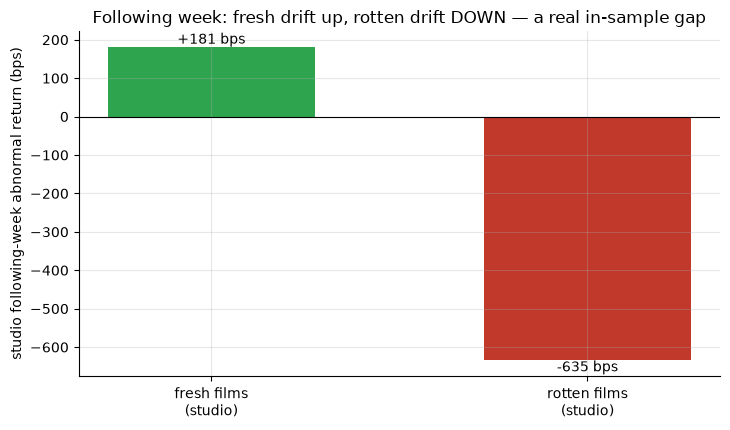

following-week gap fresh-rotten = +815.7 bps  (R: +815.7)


In [3]:
if HAVE_REAL:
    ts = st.tier_stats(EVENTS, col='fw_car')
    fb, rb = ts['fresh_bps'], ts['rotten_bps']
else:
    fb, rb = R['fw_fresh_bps'], R['fw_rotten_bps']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['fresh films\n(studio)', 'rotten films\n(studio)'], [fb, rb],
       color=[GREEN, RED], width=.55)
for i, v in enumerate([fb, rb]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('studio following-week abnormal return (bps)')
ax.set_title('Following week: fresh drift up, rotten drift DOWN — a real in-sample gap')
plt.tight_layout(); plt.show()
print(f'following-week gap fresh-rotten = {fb-rb:+.1f} bps  (R: {R["fw_gap_bps"]:+.1f})')

That's a **+816 bps** gap — rotten studios drift down ~6%, fresh drift up ~2% (market-adjusted) over the week. Shuffle the labels 20,000 times and a gap this big shows up **0.1%** of the time. In-sample, that's a real association. **So why isn't it a win?**

**Because the gap lives in exactly one window and nowhere else.** Watch the same fresh-minus-rotten gap slide across time relative to the release:

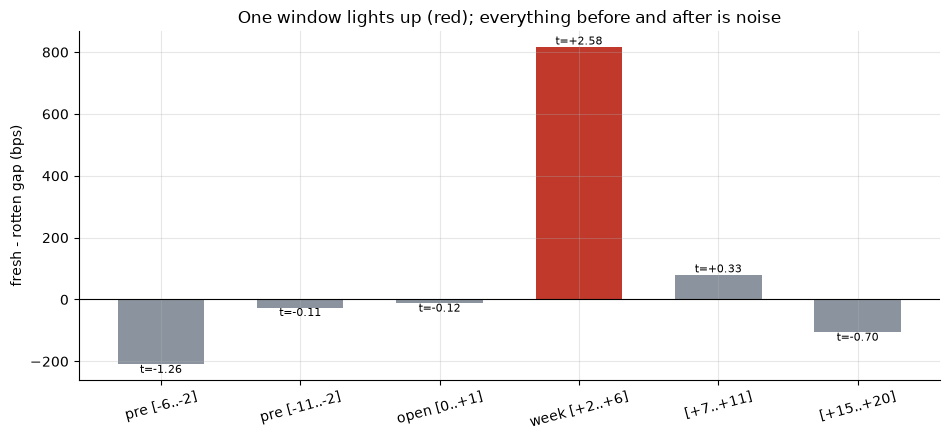

the two windows BEFORE the release are flat -> not a slow build-up; the gap has decayed to noise two weeks later -> it also reverses


In [4]:
labels = list(R['windows'].keys())
gaps = [R['windows'][k][0] for k in labels]
cols = [RED if abs(R['windows'][k][1]) >= 2 else GREY for k in labels]
fig, ax = plt.subplots(figsize=(9.6, 4.5))
ax.bar(labels, gaps, color=cols, width=.62)
for i, k in enumerate(labels):
    ax.annotate(f"t={R['windows'][k][1]:+.2f}", (i, gaps[i]), ha='center',
                va='bottom' if gaps[i] >= 0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('fresh - rotten gap (bps)')
ax.set_title('One window lights up (red); everything before and after is noise')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print('the two windows BEFORE the release are flat -> not a slow build-up; '
      'the gap has decayed to noise two weeks later -> it also reverses')

The two windows **before** the release are flat, so it's not a slow build-up; and the gap is **gone** a week later and mildly reverses after that. A genuine "the review moved the stock" effect wouldn't hide on release weekend, appear for exactly five days, then vanish.

**And the smoking gun:** the two biggest "rotten drops" aren't movies at all.

In [5]:
# the two most extreme rotten following-week 'drops' are Paramount M&A crashes
if HAVE_REAL:
    rot = EVENTS[(EVENTS['included']) & (EVENTS['tier']=='rotten')]
    worst = rot.reindex(rot['fw_car'].astype(float).sort_values().index).head(4)
    print('biggest rotten following-week moves (real tape):')
    for r in worst.itertuples():
        print(f'  {r.title:32s} {r.studio:5s} {r.date}  {r.fw_car*1e4:+.0f} bps')
else:
    print('IF (PARA, 2024-05-17):', R['outlier_if'], 'bps')
    print('Bob Marley: One Love (PARA, 2024-02-14):', R['outlier_marley'], 'bps')
print('\nThose ~ -40% weeks are PARAMOUNT crashing on its 2024 Skydance-takeover'
      ' drama — nothing to do with IF or Bob Marley being rotten.')

biggest rotten following-week moves (real tape):
  IF                               PARA  2024-05-17  -4366 bps
  Bob Marley: One Love             PARA  2024-02-14  -4050 bps
  Morbius                          SONY  2022-04-01  -818 bps
  Madame Web                       SONY  2024-02-14  -545 bps

Those ~ -40% weeks are PARAMOUNT crashing on its 2024 Skydance-takeover drama — nothing to do with IF or Bob Marley being rotten.


*IF* (−44%) and *Bob Marley: One Love* (−40%) "rotten" weeks are **Paramount crashing on 2024 takeover news** — pure confound. More generally, studios in structural decline (Warner Bros. Discovery, Paramount) tend to make *both* worse-reviewed films *and* weaker stocks in the same period. The tier isn't moving the price; it's a **flag for how the studio was already doing.**

**Could you trade the split anyway?** On paper, yes — which is exactly why we grade tradability separately.

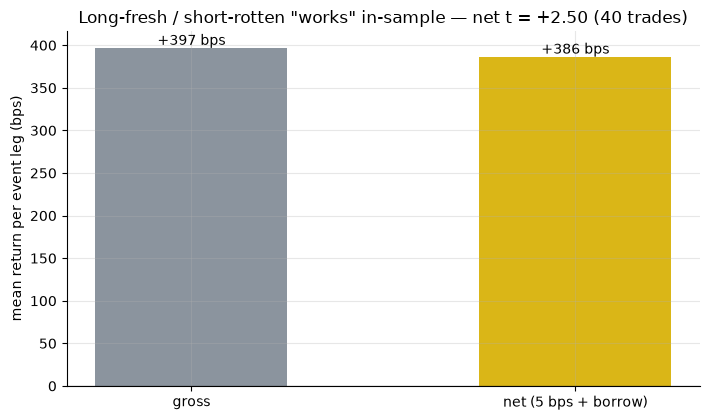

net +386 bps/leg at 5 bps costs, t = +2.50 — but it rides the one fragile window and the Paramount crash. Fragile, not investable.


In [6]:
if HAVE_REAL:
    tm0 = st.timer_stats(EVENTS, col='fw_car', cost_bps=0.0)
    tm5 = st.timer_stats(EVENTS, col='fw_car', cost_bps=5.0)
    g, n5, t5 = tm0['gross_bps'], tm5['net_bps'], tm5['t_net']
else:
    g, n5, t5 = R['timer'][0.0][0], R['timer'][5.0][1], R['timer'][5.0][2]
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(['gross', 'net (5 bps + borrow)'], [g, n5], color=[GREY, AMBER], width=.5)
for i, v in enumerate([g, n5]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean return per event leg (bps)')
ax.set_title(f'Long-fresh / short-rotten "works" in-sample — net t = {t5:+.2f} (40 trades)')
plt.tight_layout(); plt.show()
print(f'net {n5:+.0f} bps/leg at 5 bps costs, t = {t5:+.2f} — but it rides the one '
      'fragile window and the Paramount crash. Fragile, not investable.')

The book nets **+386 bps/leg** at *t* = **2.50** after costs — but it's a 40-trade backtest riding the one transient window and the one giant unrelated crash. That's a **Fragile** artifact, not a deployable edge.

## 5 · The verdict

- **Signal — Weak.** No gap on the release weekend (the clean window); a right-signed, significant gap only in the following week, but it's a single transient window, too big to be a movie, and driven by the studios' own fortunes (and one takeover crash). A real in-sample association — **not** a review effect.
- **Tradability — Fragile.** The long-short book "works" on paper but rides the fragile window and the confound.
- **"Does a flop tank the studio?" — Overstated.** The causal story isn't there; a smaller, murkier correlation is all that survives.

## 6 · Going further 🚪

- **The honest limit is power and attribution.** 40 events, each a noisy five-day window, and a signal that can't be cleanly separated from "which studios were sinking that year." A bigger sample and a studio-fixed-effects design (does a rotten film hurt *the same studio* vs its own average?) is the natural next step.
- **Where a real version might live:** the *pure-play* film names (a studio that is mostly one franchise), or intraday reaction to the review-embargo lift rather than a five-day close-to-close window that swallows unrelated news.
- **Sibling studies:** [771-box-office-bomb](../../771-box-office-bomb/) (sell Disney after a flop), [550-box-office-momentum](../../550-box-office-momentum/) (box-office revenue momentum), [296-oscars-effect](../../296-oscars-effect/) (the awards channel) and [552-app-store-rankings](../../552-app-store-rankings/) (product ratings for tech). Same "public rating → stock" question, different signals.

*Think a studio-fixed-effects design on pure-play names would isolate a real review effect? Show it — out of sample, after costs — then we'll talk.*